<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana6/Dia_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DIA 2: O ARSENAL COMPLETO (EDA, ARQUITETURA BLINDADA E AUDITORIA)

-> 1. Baixando e estruturando o dataset de células de malária (NIH)...
Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.

-> 2. Análise Exploratória: O que a Inteligência Artificial vai enfrentar?


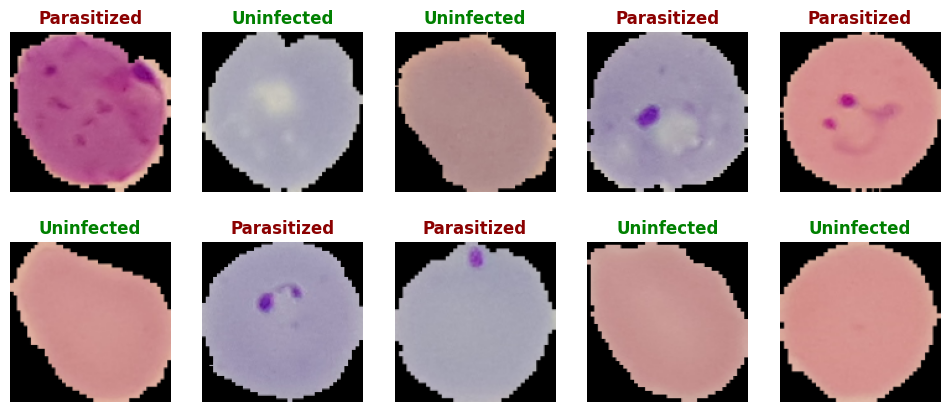


-> 3. Aplicando mutações físicas (Augmentation) apenas no Treino...

-> 4. Montando a Rede Neural com BatchNormalization e Dropout...

-> 5. Iniciando o treinamento imunizado...
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1439s 2s/step - accuracy: 0.6632 - loss: 0.6840 - val_accuracy: 0.6500 - val_loss: 0.7200
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1395s 2s/step - accuracy: 0.8637 - loss: 0.2943 - val_accuracy: 0.8396 - val_loss: 0.4149
Epoch 3/10
377/689 ━━━━━━━━━━━━━━━━━━━━ 10:04 2s/step - accuracy: 0.9189 - loss: 0.2275

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("="*75)
print("DIA 2: O ARSENAL COMPLETO (EDA, ARQUITETURA BLINDADA E AUDITORIA)")
print("="*75)

# ==============================================================================
# 1. DOWNLOAD DIRETO E INGESTÃO (VIA LINUX)
# ==============================================================================
print("\n-> 1. Baixando e estruturando o dataset de células de malária (NIH)...")
!wget -q -nc https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
!unzip -q -n cell_images.zip

pasta_base = 'cell_images'

dados_treino = tf.keras.utils.image_dataset_from_directory(
    pasta_base, validation_split=0.2, subset="training", seed=123,
    image_size=(130, 130), batch_size=32
)

dados_val = tf.keras.utils.image_dataset_from_directory(
    pasta_base, validation_split=0.2, subset="validation", seed=123,
    image_size=(130, 130), batch_size=32
)

nomes_classes = dados_treino.class_names # ['Parasitized', 'Uninfected']

# ==============================================================================
# 2. ANÁLISE EXPLORATÓRIA VISUAL (EDA)
# ==============================================================================
print("\n-> 2. Análise Exploratória: O que a Inteligência Artificial vai enfrentar?")
plt.figure(figsize=(12, 5))
# Puxamos 1 lote (batch) de 32 imagens e exibimos as 10 primeiras
for imagens, rotulos in dados_treino.take(1):
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(imagens[i].numpy().astype("uint8"))
        # Parasitized = 0 (Vermelho), Uninfected = 1 (Verde)
        cor = "darkred" if rotulos[i] == 0 else "green"
        plt.title(nomes_classes[rotulos[i]], color=cor, fontweight='bold')
        plt.axis("off")
plt.show()

# ==============================================================================
# 3. AUGMENTATION DINÂMICO E OTIMIZAÇÃO
# ==============================================================================
print("\n-> 3. Aplicando mutações físicas (Augmentation) apenas no Treino...")
def augmentation_avancado(imagem, rotulo):
    imagem = tf.image.random_brightness(imagem, max_delta=0.2)
    imagem = tf.image.random_contrast(imagem, lower=0.8, upper=1.2)
    imagem = tf.image.random_flip_left_right(imagem)
    imagem = tf.image.random_flip_up_down(imagem)
    return tf.clip_by_value(imagem, 0.0, 255.0), rotulo

dados_treino_aug = dados_treino.map(augmentation_avancado).prefetch(tf.data.AUTOTUNE)
dados_val = dados_val.cache().prefetch(tf.data.AUTOTUNE)

# ==============================================================================
# 4. A ARQUITETURA BLINDADA
# ==============================================================================
print("\n-> 4. Montando a Rede Neural com BatchNormalization e Dropout...")
modelo_blindado = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(130, 130, 3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5), # A vacina contra memorização
    tf.keras.layers.Dense(1, activation='sigmoid') # Binário: 0 ou 1
])

modelo_blindado.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ==============================================================================
# 5. TREINAMENTO
# ==============================================================================
print("\n-> 5. Iniciando o treinamento imunizado...")
freio = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

historico = modelo_blindado.fit(
    dados_treino_aug,
    validation_data=dados_val,
    epochs=10,
    callbacks=[freio],
    verbose=1
)

# ==============================================================================
# 6. ELETROCARDIOGRAMA (LOSS E ACURÁCIA)
# ==============================================================================
print("\n-> 6. Diagnóstico de Saúde da Rede:")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Treino (Loss)', color='blue', linewidth=2)
plt.plot(historico.history['val_loss'], label='Validação (Loss)', color='green', linewidth=2)
plt.title("O Fim do Jacaré: Curvas Estabilizadas")
plt.xlabel("Épocas")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historico.history['accuracy'], label='Treino (Acc)', color='blue')
plt.plot(historico.history['val_accuracy'], label='Validação (Acc)', color='green')
plt.title("Acurácia")
plt.xlabel("Épocas")
plt.legend()
plt.show()

# ==============================================================================
# 7. AUDITORIA (MATRIZ E RELATÓRIO)
# ==============================================================================
print("\n" + "="*75)
print("AUDITORIA MÉDICA: TESTANDO NO MUNDO REAL (DADOS DE VALIDAÇÃO)")
print("="*75)

gabaritos = []
chutes_probabilidade = []

# Extraindo os dados do gerador de validação de forma eficiente
for imagens, rotulos in dados_val:
    probs = modelo_blindado.predict(imagens, verbose=0)
    chutes_probabilidade.extend(probs)
    gabaritos.extend(rotulos.numpy())

gabaritos = np.array(gabaritos)
chutes_finais = (np.array(chutes_probabilidade) > 0.5).astype(int).flatten()

print("\n[RELATÓRIO DE CLASSIFICAÇÃO]")
print(classification_report(gabaritos, chutes_finais, target_names=nomes_classes))

plt.figure(figsize=(6, 4))
matriz = confusion_matrix(gabaritos, chutes_finais)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title("Matriz de Confusão: Células de Malária")
plt.ylabel("Exame Laboratorial (Real)")
plt.xlabel("Diagnóstico da IA (Predição)")
plt.show()

# ==============================================================================
# 8. TESTE VISUAL: O MODELO ACERTA MESMO?
# ==============================================================================
print("\n-> Sorteando 4 células do Teste Cego para a Prova Final:")

plt.figure(figsize=(12, 3))
for imagens, rotulos in dados_val.take(1):
    predicoes = modelo_blindado.predict(imagens, verbose=0)

    for i in range(4):
        ax = plt.subplot(1, 4, i + 1)
        plt.imshow(imagens[i].numpy().astype("uint8"))

        # Traduzindo o número em texto
        real_idx = rotulos[i].numpy()
        chute_idx = int(predicoes[i][0] > 0.5)

        real_texto = nomes_classes[real_idx]
        chute_texto = nomes_classes[chute_idx]

        # Lógica de Certeza (Se for 0, inverte a probabilidade para ler visualmente)
        certeza = predicoes[i][0] if chute_idx == 1 else (1 - predicoes[i][0])
        certeza *= 100

        cor = "green" if real_idx == chute_idx else "red"

        plt.title(f"Real: {real_texto}\nIA: {chute_texto} ({certeza:.1f}%)", color=cor, fontweight='bold', fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()